# Enrichment Analysis

Uranium enrichment — the U-235 atom fraction relative to total uranium — is
the defining quantity in nuclear safeguards and non-proliferation assessments.
VENUS measures it non-destructively by exploiting the distinct neutron resonance
fingerprints of U-235 and U-238 in the 1–50 eV range.

This notebook demonstrates spatial enrichment mapping on a synthetic 20×20 pixel
phantom with three enrichment zones (3%, 20%, 50%).

| Step | Content |
|------|---------|
| 1. Cross-sections | Compare U-235 vs U-238 spectral fingerprints |
| 2. Phantom | Define spatially varying enrichment map |
| 3. Forward model | Generate (n_energies, H, W) transmission cube |
| 4. Noise | Poisson simulation (I₀ = 500) |
| 5. Spatial map | Per-pixel U-235/U-238 density fit |
| 6. Enrichment | Compute fitted enrichment = n(U-235) / n(U-total) |
| 7. Validation | Compare fitted vs true enrichment map |
| 8. Statistics | Per-zone bias and precision |

## Physics background

| Grade | Enrichment | Typical use |
|-------|-----------|-------------|
| Natural | 0.72% | Shielding, natural-U reactor |
| LEU | 3–20% | Nuclear power reactors |
| HEU | > 20% | Research reactors, weapons |

Enrichment fraction: $e = n_\text{U-235} / (n_\text{U-235} + n_\text{U-238})$

## Prerequisites

```bash
pixi run build
```

**Previous:** [Spatial Mapping — Synthetic](04_spatial_mapping_synthetic.ipynb)  
**Next:** [Trace Analysis](02_trace_analysis.ipynb)

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

import nereids

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 12

## 1. U-235 vs U-238 Spectral Fingerprints

U-235 (odd-A, fissile) has a high resonance density — many overlapping peaks
spread throughout the 1–50 eV range.
U-238 (even-A, fertile) has isolated, very strong resonances, with the first at
6.67 eV dominating the spectrum. This contrast is what makes spectral discrimination
between the two isotopes possible.

ResonanceData(Z=92, A=235, AWR=233.025, n_resonances=3194)
ResonanceData(Z=92, A=238, AWR=236.006, n_resonances=3345)


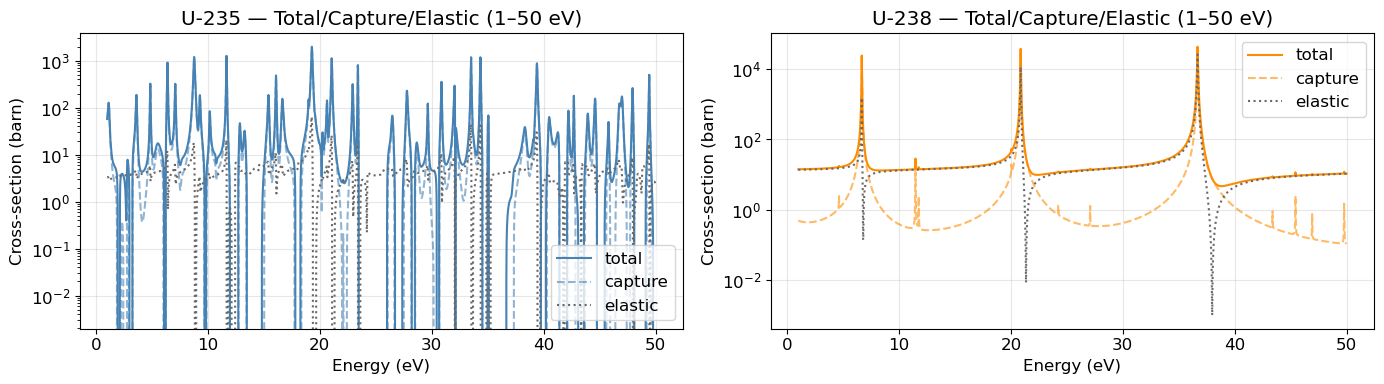

U-235 resonances (L-groups): [0]
U-238 resonances (L-groups): [0, 1]


In [2]:
u235 = nereids.load_endf(92, 235)
u238 = nereids.load_endf(92, 238)

print(u235)
print(u238)

# Fine grid for cross-section visualisation only
e_fine = np.linspace(1.0, 50.0, 4000)
xs_u235 = nereids.cross_sections(e_fine, u235)
xs_u238 = nereids.cross_sections(e_fine, u238)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, xs, name, color in [
    (axes[0], xs_u235, 'U-235', 'steelblue'),
    (axes[1], xs_u238, 'U-238', 'darkorange'),
]:
    ax.semilogy(e_fine, xs['total'],   color=color,      label='total')
    ax.semilogy(e_fine, xs['capture'], color=color,      label='capture', linestyle='--', alpha=0.6)
    ax.semilogy(e_fine, xs['elastic'], color='dimgray',  label='elastic', linestyle=':')
    ax.set_xlabel('Energy (eV)')
    ax.set_ylabel('Cross-section (barn)')
    ax.set_title(f'{name} — Total/Capture/Elastic (1–50 eV)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'U-235 resonances (L-groups): {u235.l_values}')
print(f'U-238 resonances (L-groups): {u238.l_values}')

## 2. Define Enrichment Phantom

The phantom is a uranium metal sample ($N_\text{total}$ = 0.005 atoms/barn,
corresponding to ~1 mm of U metal) with three enrichment zones.
The total uranium density is constant; only the U-235/U-238 split changes.

| Zone | Rows | Cols | Enrichment | n(U-235) | n(U-238) |
|------|------|------|-----------|----------|----------|
| Background | all | all | 3% (LEU) | 0.00015 | 0.00485 |
| Enriched band | 5–14 | 4–15 | 20% | 0.001 | 0.004 |
| HEU inclusion | 8–11 | 8–11 | 50% | 0.0025 | 0.0025 |

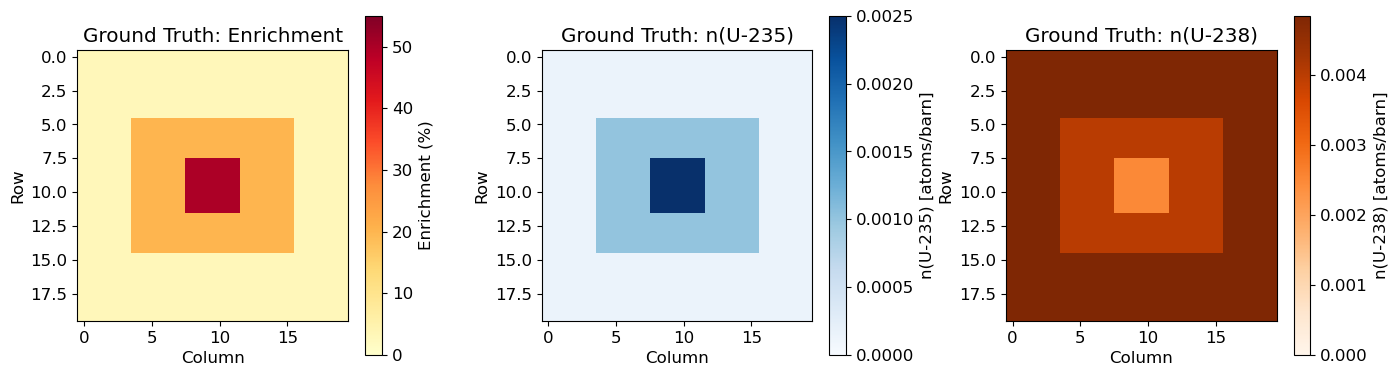

Unique enrichment levels: [ 3. 20. 50.]
n(U-235) range: 0.00015 – 0.00250 atoms/barn
n(U-238) range: 0.00250 – 0.00485 atoms/barn


In [3]:
H, W = 20, 20
N_TOTAL = 0.005  # total uranium areal density [atoms/barn] — constant

# Enrichment fraction (atom fraction of U-235)
true_enrichment = np.full((H, W), 0.03)
true_enrichment[5:15, 4:16] = 0.20
true_enrichment[8:12, 8:12] = 0.50

# Individual isotope densities derived from enrichment
true_n_u235 = true_enrichment * N_TOTAL
true_n_u238 = (1.0 - true_enrichment) * N_TOTAL

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(true_enrichment * 100, cmap='YlOrRd', vmin=0, vmax=55, interpolation='nearest')
im1 = axes[1].imshow(true_n_u235, cmap='Blues',   vmin=0, interpolation='nearest')
im2 = axes[2].imshow(true_n_u238, cmap='Oranges', vmin=0, interpolation='nearest')

plt.colorbar(im0, ax=axes[0], label='Enrichment (%)')
plt.colorbar(im1, ax=axes[1], label='n(U-235) [atoms/barn]')
plt.colorbar(im2, ax=axes[2], label='n(U-238) [atoms/barn]')

axes[0].set_title('Ground Truth: Enrichment')
axes[1].set_title('Ground Truth: n(U-235)')
axes[2].set_title('Ground Truth: n(U-238)')

for ax in axes:
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')

plt.tight_layout()
plt.show()

unique_enr = np.unique(true_enrichment)
print(f'Unique enrichment levels: {unique_enr * 100}')
print(f'n(U-235) range: {true_n_u235.min():.5f} – {true_n_u235.max():.5f} atoms/barn')
print(f'n(U-238) range: {true_n_u238.min():.5f} – {true_n_u238.max():.5f} atoms/barn')

## 3. Generate Transmission Cube

Only three unique compositions exist across 400 pixels, so we compute three
forward-model spectra and broadcast them to fill the full cube.

**Note:** The strong U-238 resonance at 6.67 eV saturates (T ≈ 0) even for thin
samples — this is physically correct and appears as a sharp dip in the spectrum.
The fitting handles saturated bins naturally via the Poisson uncertainty model.

Computing 3 unique spectra for 400 pixels ...
  Composition 0: enrichment=3%  T_min=0.0000
  Composition 1: enrichment=20%  T_min=0.0000
  Composition 2: enrichment=50%  T_min=0.0000


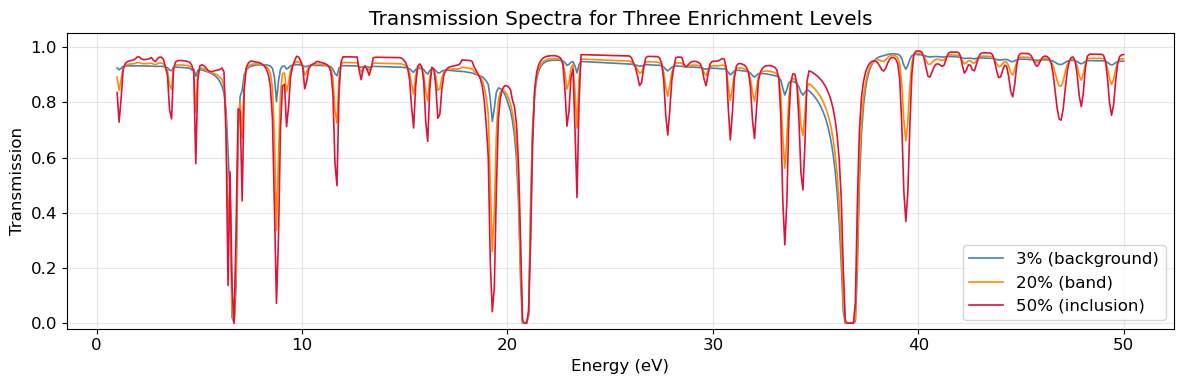

In [4]:
# 500-point grid over 1–50 eV (VENUS measurement range)
energies = np.linspace(1.0, 50.0, 500)

# VENUS beamline parameters (shared with spatial_map)
FLIGHT_PATH_M = 25.0
DELTA_T_US = 0.3
DELTA_L_M = 0.01
TEMP_K = 293.6

# Pre-compute spectra for unique compositions
compositions = np.stack([true_n_u235.ravel(), true_n_u238.ravel()], axis=1)
unique_comps, pixel_indices = np.unique(compositions, axis=0, return_inverse=True)

print(f'Computing {len(unique_comps)} unique spectra for {H * W} pixels ...')

unique_spectra = {}
for i, (n_235, n_238) in enumerate(unique_comps):
    t = nereids.forward_model(
        energies,
        [(u235, float(n_235)), (u238, float(n_238))],
        temperature_k=TEMP_K,
        flight_path_m=FLIGHT_PATH_M,
        delta_t_us=DELTA_T_US,
        delta_l_m=DELTA_L_M,
    )
    e_pct = n_235 / (n_235 + n_238) * 100
    unique_spectra[i] = t
    print(f'  Composition {i}: enrichment={e_pct:.0f}%  T_min={t.min():.4f}')

transmission_true = np.stack(
    [unique_spectra[idx] for idx in pixel_indices], axis=1
).reshape(len(energies), H, W)

# Overlay the three spectra to show how enrichment level changes the pattern
fig, ax = plt.subplots(figsize=(12, 4))
labels = ['3% (background)', '20% (band)', '50% (inclusion)']
colors = ['steelblue', 'darkorange', 'crimson']
for i, (label, color) in enumerate(zip(labels, colors)):
    ax.plot(energies, unique_spectra[i], color=color, lw=1.2, label=label)
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Transmission')
ax.set_title('Transmission Spectra for Three Enrichment Levels')
ax.legend()
ax.set_ylim(-0.02, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Add Poisson Noise

We use I₀ = 500 counts/bin — slightly higher than T2-4 because the U-235
signal in the 3%-enriched background is weak and requires better statistics
for reliable density recovery.

Mean transmission:         0.8776
Mean relative uncertainty: 4.7%


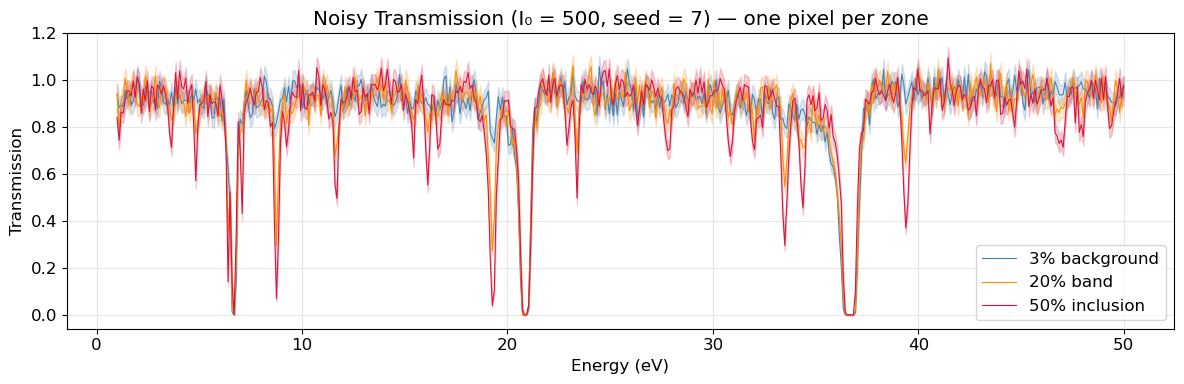

In [5]:
I0 = 500
rng = np.random.default_rng(7)

counts = rng.poisson(I0 * transmission_true)
transmission_noisy = counts / I0           # preserve raw zeros — saturated bins are physically T≈0
uncertainty = np.sqrt(np.maximum(counts, 1)) / I0  # clamp only in uncertainty denominator

print(f'Mean transmission:         {transmission_noisy.mean():.4f}')
# Use ratio-of-means: the per-bin ratio mean(σ/T) diverges at U-235/Pu-241 resonance
# bottoms where T→0, so it is not a useful summary statistic.
print(f'Mean relative uncertainty: {uncertainty.mean() / transmission_noisy.mean() * 100:.1f}%')

# Show spectrum at the central pixel of each zone.
# (10, 5): row 10 is in the 20%-band [5:15], col 5 is in [4:16], but outside inclusion [8:12, 8:12].
zone_pixels = [
    (0,  0,  '3% background'),
    (10, 5,  '20% band'),
    (9,  9,  '50% inclusion'),
]

fig, ax = plt.subplots(figsize=(12, 4))
palette = ['steelblue', 'darkorange', 'crimson']
for (row, col, label), color in zip(zone_pixels, palette):
    t_meas = transmission_noisy[:, row, col]
    sig    = uncertainty[:, row, col]
    ax.fill_between(energies, t_meas - sig, t_meas + sig, alpha=0.2, color=color)
    ax.plot(energies, t_meas, color=color, lw=0.8, label=label)

ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Transmission')
ax.set_title(f'Noisy Transmission (I\u2080 = {I0}, seed = 7) — one pixel per zone')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Run Spatial Mapping

`spatial_map()` fits U-235 and U-238 densities independently at every pixel.
The enrichment map is then derived in post-processing from the fitted density
ratio — the fitting itself knows nothing about the total-density constraint.

In [6]:
t0 = time.perf_counter()

result = nereids.spatial_map(
    transmission_noisy,
    uncertainty,
    energies,
    [u235, u238],
    temperature_k=TEMP_K,
    initial_densities=[0.001, 0.003],   # rough prior for LEU uranium
    flight_path_m=FLIGHT_PATH_M,
    delta_t_us=DELTA_T_US,
    delta_l_m=DELTA_L_M,
    max_iter=200,
)

elapsed = time.perf_counter() - t0
print(f'Spatial mapping: {elapsed:.2f} s  ({H * W} pixels)')
print(f'Converged: {result.n_converged}/{result.n_total}  ({result.n_converged / result.n_total * 100:.1f}%)')
print(f'Isotope names: {result.isotope_names}')

density_maps = np.array(result.density_maps)    # (2, H, W)
unc_maps     = np.array(result.uncertainty_maps) # (2, H, W)
chi2 = np.array(result.chi_squared_map)          # (H, W)
conv = np.array(result.converged_map)            # (H, W) bool

n235_fit = density_maps[0]   # U-235 fitted density
n238_fit = density_maps[1]   # U-238 fitted density

print(f'\nFitted n(U-235) range: {n235_fit.min():.5f} – {n235_fit.max():.5f} atoms/barn')
print(f'Fitted n(U-238) range: {n238_fit.min():.5f} – {n238_fit.max():.5f} atoms/barn')

Spatial mapping: 0.03 s  (400 pixels)
Converged: 400/400  (100.0%)
Isotope names: ['U-235', 'U-238']

Fitted n(U-235) range: 0.00010 – 0.00259 atoms/barn
Fitted n(U-238) range: 0.00242 – 0.00514 atoms/barn


## 6. Compute Enrichment Map

Enrichment is derived from the fitted densities:
$$e_\text{fit} = \frac{n_\text{U-235}}{n_\text{U-235} + n_\text{U-238}}$$

The uncertainty is propagated via the delta method:
$$\sigma_e = \frac{\sqrt{\sigma_{235}^2 \, n_{238}^2 + \sigma_{238}^2 \, n_{235}^2}}{(n_{235} + n_{238})^2}$$

In [7]:
n_total_fit = n235_fit + n238_fit
# Guard against near-zero total density (non-converged pixels)
n_total_safe = np.where(n_total_fit > 1e-8, n_total_fit, 1e-8)

fitted_enrichment = n235_fit / n_total_safe

# Uncertainty propagation
sigma_235 = unc_maps[0]
sigma_238 = unc_maps[1]
sigma_enrichment = np.sqrt(
    (sigma_235 * n238_fit)**2 + (sigma_238 * n235_fit)**2
) / n_total_safe**2

print(f'Fitted enrichment range: {fitted_enrichment.min() * 100:.1f}% – {fitted_enrichment.max() * 100:.1f}%')
print(f'Mean enrichment uncertainty: {sigma_enrichment.mean() * 100:.2f}%')

Fitted enrichment range: 2.1% – 51.5%
Mean enrichment uncertainty: 0.43%


## 7. Compare Fitted vs True Enrichment Map

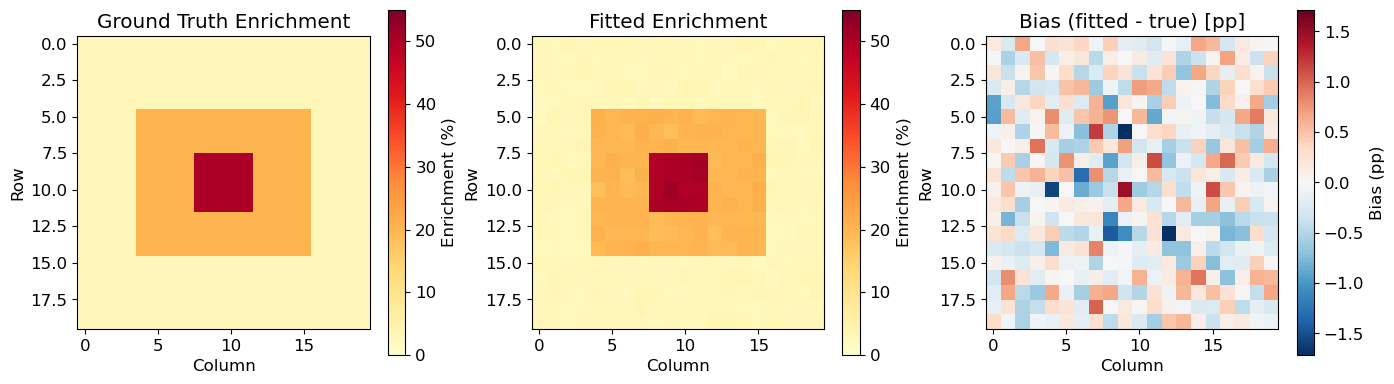

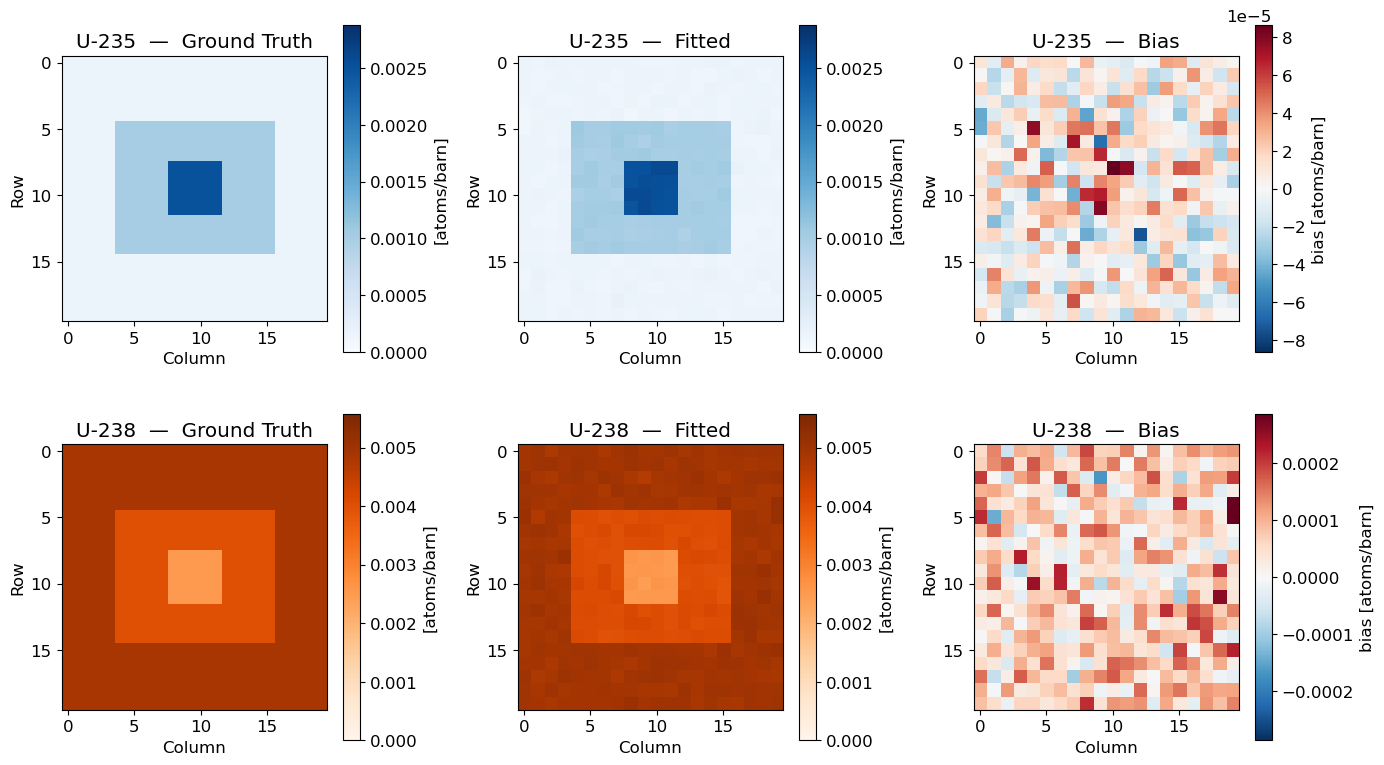

In [8]:
enr_bias = (fitted_enrichment - true_enrichment) * 100  # absolute bias in %

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(true_enrichment * 100, cmap='YlOrRd', vmin=0, vmax=55, interpolation='nearest')
im1 = axes[1].imshow(fitted_enrichment * 100, cmap='YlOrRd', vmin=0, vmax=55, interpolation='nearest')
vlim = np.abs(enr_bias).max()
im2 = axes[2].imshow(enr_bias, cmap='RdBu_r', vmin=-vlim, vmax=vlim, interpolation='nearest')

plt.colorbar(im0, ax=axes[0], label='Enrichment (%)')
plt.colorbar(im1, ax=axes[1], label='Enrichment (%)')
plt.colorbar(im2, ax=axes[2], label='Bias (pp)')

axes[0].set_title('Ground Truth Enrichment')
axes[1].set_title('Fitted Enrichment')
axes[2].set_title('Bias (fitted - true) [pp]')

for ax in axes:
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')

plt.tight_layout()
plt.show()

# Density maps comparison
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
names_iso = result.isotope_names
truths_iso = [true_n_u235, true_n_u238]
cmaps_iso  = ['Blues', 'Oranges']

for row_i, (name, truth, fitted, cmap) in enumerate(zip(names_iso, truths_iso, density_maps, cmaps_iso)):
    vmax = truth.max() * 1.15
    bias = fitted - truth
    vlim = np.abs(bias).max()
    im0 = axes[row_i, 0].imshow(truth,  cmap=cmap,     vmin=0,     vmax=vmax, interpolation='nearest')
    im1 = axes[row_i, 1].imshow(fitted, cmap=cmap,     vmin=0,     vmax=vmax, interpolation='nearest')
    im2 = axes[row_i, 2].imshow(bias,   cmap='RdBu_r', vmin=-vlim, vmax=vlim, interpolation='nearest')
    plt.colorbar(im0, ax=axes[row_i, 0], label='[atoms/barn]')
    plt.colorbar(im1, ax=axes[row_i, 1], label='[atoms/barn]')
    plt.colorbar(im2, ax=axes[row_i, 2], label='bias [atoms/barn]')
    axes[row_i, 0].set_title(f'{name}  —  Ground Truth')
    axes[row_i, 1].set_title(f'{name}  —  Fitted')
    axes[row_i, 2].set_title(f'{name}  —  Bias')
    for ax in axes[row_i]:
        ax.set_xlabel('Column')
        ax.set_ylabel('Row')

plt.tight_layout()
plt.show()

## 8. Quantitative Validation

For each composition zone we report:
- **Enrichment** (true vs mean fitted vs fitted std)
- **Bias in percentage points** (pp)
- **Individual density bias** for U-235 and U-238

In [9]:
zones = [
    ('Background (3%)',  (true_enrichment == 0.03), 0.03,  0.00015, 0.00485),
    ('Band (20%)',       (true_enrichment == 0.20), 0.20,  0.001,   0.004),
    ('Inclusion (50%)',  (true_enrichment == 0.50), 0.50,  0.0025,  0.0025),
]

print('=== Enrichment Recovery ===')
print(f'{"Zone":<20} {"True e":>8} {"Mean fit":>10} {"Std":>8} {"Bias (pp)":>10}')
print('-' * 60)
for zone_name, mask, true_e, _, _ in zones:
    vals = fitted_enrichment[mask]
    mean_e = vals.mean()
    std_e  = vals.std()
    bias_pp = (mean_e - true_e) * 100
    print(f'{zone_name:<20} {true_e * 100:>7.0f}% {mean_e * 100:>9.2f}% {std_e * 100:>7.2f}% {bias_pp:>9.2f}')

print()
print('=== Density Recovery ===')
print(f'{"Zone":<20} {"Isotope":<8} {"True":>10} {"Mean fit":>10} {"Std":>10} {"Bias":>8}')
print('-' * 70)
for zone_name, mask, _, true_u235_n, true_u238_n in zones:
    for iso_idx, (iso_name, true_n) in enumerate([('U-235', true_u235_n), ('U-238', true_u238_n)]):
        vals = density_maps[iso_idx][mask]
        mean_fit = vals.mean()
        std_fit  = vals.std()
        bias_pct = (mean_fit - true_n) / true_n * 100
        print(f'{zone_name:<20} {iso_name:<8} {true_n:>10.5f} {mean_fit:>10.6f} {std_fit:>10.6f} {bias_pct:>7.1f}%')
    print()

=== Enrichment Recovery ===
Zone                   True e   Mean fit      Std  Bias (pp)
------------------------------------------------------------
Background (3%)            3%      3.01%    0.39%      0.01
Band (20%)                20%     19.90%    0.56%     -0.10
Inclusion (50%)           50%     50.02%    0.62%      0.02

=== Density Recovery ===
Zone                 Isotope        True   Mean fit        Std     Bias
----------------------------------------------------------------------
Background (3%)      U-235       0.00015   0.000152   0.000020     1.6%
Background (3%)      U-238       0.00485   0.004918   0.000073     1.4%

Band (20%)           U-235       0.00100   0.001008   0.000027     0.8%
Band (20%)           U-238       0.00400   0.004060   0.000068     1.5%

Inclusion (50%)      U-235       0.00250   0.002533   0.000033     1.3%
Inclusion (50%)      U-238       0.00250   0.002531   0.000051     1.2%



## Summary

This notebook demonstrated non-destructive uranium enrichment mapping:

1. **Spectral fingerprints** — U-235 (many weak resonances) vs U-238 (few strong resonances)
   are the basis for isotopic discrimination
2. **Phantom** — three enrichment zones (3%, 20%, 50%) encoded in a 20×20 synthetic image
3. **Spatial mapping** — `spatial_map()` recovered U-235 and U-238 densities independently
4. **Derived enrichment** — computed from fitted density ratio, not directly fitted
5. **Uncertainty propagation** — enrichment uncertainty derived via the delta method

### Enrichment from density maps

```python
density_maps = np.array(result.density_maps)  # (2, H, W): [U-235, U-238]
n235, n238 = density_maps

enrichment = n235 / (n235 + n238)             # atom fraction of U-235
```

### Typical detection limits at VENUS

With I₀ = 500 and N_total = 0.005 atoms/barn, enrichment can be recovered
to within ~1–3 pp for zones with at least 4×4 = 16 pixels.
Improving statistics (higher I₀, longer count time, or spatial averaging)
reduces the detection limit proportionally to $1/\sqrt{I_0}$.

**Previous:** [Spatial Mapping — Synthetic](04_spatial_mapping_synthetic.ipynb)  
**Next:** [Trace Analysis](02_trace_analysis.ipynb)